In [8]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

(2160, 4)
precipitation    float64
temperature      float64
humidity         float64
label             object
dtype: object
precipitation    0
temperature      0
humidity         0
label            0
dtype: int64
                count unique              top  freq       mean        std  \
precipitation  2160.0    NaN              NaN   NaN   0.223472   0.780144   
temperature    2160.0    NaN              NaN   NaN  24.060278   3.214115   
humidity       2160.0    NaN              NaN   NaN  77.034722  16.380017   
label            2160      4  Disiram sedikit  1446        NaN        NaN   

                min   25%   50%   75%    max  
precipitation   0.0   0.0   0.0   0.1   11.2  
temperature    16.7  21.5  23.5  26.6   32.2  
humidity       32.0  65.0  81.0  91.0  100.0  
label           NaN   NaN   NaN   NaN    NaN  
Validation accuracy: 1.0
                 precision    recall  f1-score   support

 Disiram Banyak       1.00      1.00      1.00        24
 Disiram Normal       1.00

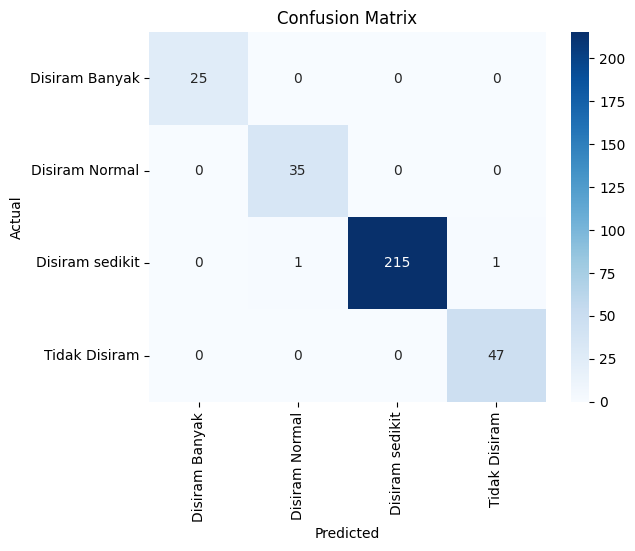

In [10]:
df = pd.read_csv('DataFinalv1.csv')
print(df.shape)
print(df.dtypes)
print(df.isna().sum().sort_values(ascending=False).head(10))
print(df.describe(include='all').T)

model = joblib.load(r"D:\Materi\WeatherAI-main\WeatherAI-main\WeatherAIv2.joblib")

TARGET = "label"

X = df[['precipitation', 'humidity', 'temperature']]
y = df[TARGET]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

y_val_pred = model.predict(X_valid)
print("Validation accuracy:", accuracy_score(y_valid, y_val_pred))
print(classification_report(y_valid, y_val_pred))

y_test_pred = model.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=model.classes_, yticklabels=model.classes_, cmap="Blues")
plt.title(f"Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

